In [3]:
import numpy as np
import matplotlib.pyplot as plt

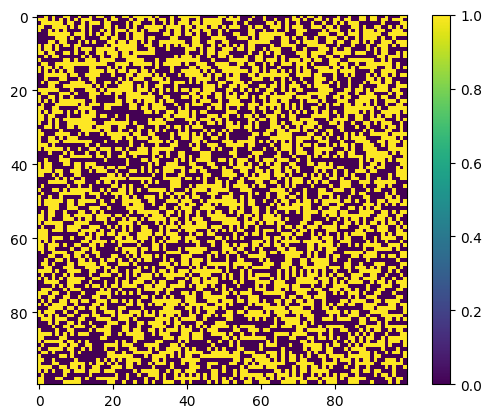

In [40]:
#assign a certain random contagion distribution to the population
np.random.seed(0)
initial_infected_pop = np.random.randint(0, 2, (100, 100), dtype=np.int8)
plt.imshow(initial_infected_pop)
plt.colorbar()

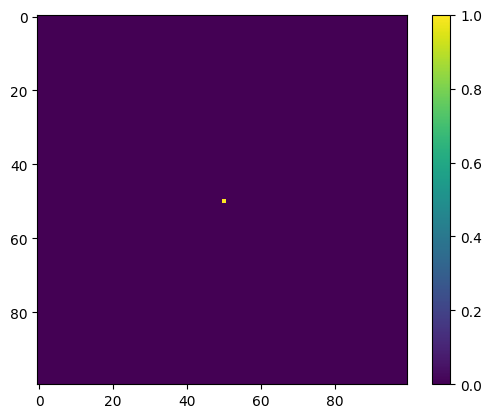

In [30]:
#assign a centered contagion person into the population
initial_infected_pop = np.zeros((100, 100), dtype=np.int8)
initial_infected_pop[50, 50] = 1
plt.imshow(initial_infected_pop)
plt.colorbar()

In [ ]:
#use np.roll to check the contagion proability 
nord = np.roll(initial_infected_pop, 1, axis=0)
sud = np.roll(initial_infected_pop, -1, axis=0)
est = np.roll(initial_infected_pop, 1, axis=1)
ovest = np.roll(initial_infected_pop, -1, axis=1)

neigh = nord + est + sud + ovest

plt.imshow(neigh)
plt.colorbar()

In [ ]:
# a persone is infected if at least 2 of its neighbors are infected
candidates = np.where(neigh > 3, 1, 0)
plt.imshow(candidates)
plt.colorbar()

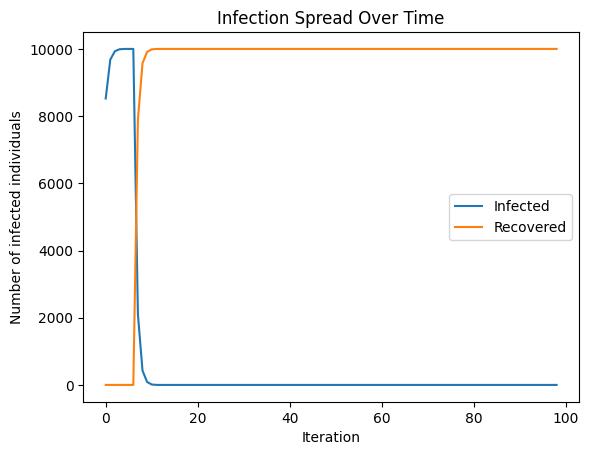

In [51]:

number_of_infected = []
number_of_recovered = []

total_time = 100

evolution = np.empty((100, 100, total_time), dtype=np.int8)
evolution[:, :, 0] = initial_infected_pop
recover_time = 5

for i in range(99):
    infected_pop = evolution[:, :, i]
    #use np.roll to check the contagion proability 
    nord = np.roll(infected_pop, 1, axis=0)
    est = np.roll(infected_pop, 1, axis=1)
    sud = np.roll(infected_pop, -1, axis=0)
    ovest = np.roll(infected_pop, -1, axis=1)

    neigh =   np.where(nord == 1, 1, 0) + np.where(est == 1, 1, 0) + np.where(sud == 1, 1, 0) + np.where(ovest == 1, 1, 0) 

    # plt.imshow(neigh)
    # plt.colorbar()

    # a person is infected if at least 2 of its neighbors are infected
    candidates = np.where(neigh >= 2 , 1, 0)
    # plt.imshow(candidates)
    # plt.colorbar()

    infected_pop = np.where(candidates == 1, 1, infected_pop)
    if i > recover_time:
        recovered = np.where(evolution[:, :, i-recover_time] == 1, 2, infected_pop)
        evolution[:, :, i + 1] = np.where(recovered == 2, recovered, infected_pop)
    else:
        evolution[:, :, i + 1] = infected_pop
    # plt.imshow(infected_pop)
    # plt.colorbar()
    # plt.show()
    # plt.close()
    # print(f"Iteration {i+1}: {np.sum(infected_pop)} infected individuals")
    number_of_infected.append(np.sum(np.where(infected_pop==1, 1, 0)))
    number_of_recovered.append(np.sum(np.where(infected_pop==2, 1, 0)))


plt.plot(number_of_infected, label='Infected')
plt.plot(number_of_recovered, label='Recovered')
plt.xlabel('Iteration')
plt.ylabel('Number of infected individuals')
plt.title('Infection Spread Over Time')
plt.legend()
plt.show()

In [ ]:
from matplotlib.colors import ListedColormap, BoundaryNorm

cmap = ListedColormap(['blue', 'red', 'yellow'])
norm = BoundaryNorm([0, 1, 2, 3], cmap.N)  # confini: [0,1), [1,2), [2,3)

#interactive plot the tensor evolution
# Funzione di plotting
def plot_slice(z_index):
    plt.figure(figsize=(6, 6))
    plt.imshow(evolution[:, :, z_index], cmap=cmap, norm=norm, origin='lower')
    plt.title(f'Slice z = {z_index}')
    cbar = plt.colorbar(ticks=[0, 1, 2])
    cbar.set_label('State')

    plt.show()
    
# Creazione del widget interattivo
from ipywidgets import interact
import ipywidgets as widgets
from IPython.display import display
# Creazione del widget interattivo
interact(plot_slice, z_index=widgets.IntSlider(min=0, max=total_time-1, step=1, value=0))

interactive(children=(IntSlider(value=0, description='z_index', max=99), Output()), _dom_classes=('widget-inte…

<function __main__.plot_slice(z_index)>